# **DISCLAIMER: YOU MUST PUT BOTH CSV FILES IN YOUR HOME "MY DRIVE" FOLDER IN GOOGLE DRIVE IN ORDER FOR THE NEXT STEP TO WORK**

# **Final Report**

**UNI:**  mhs2229, sz3388, lj2496

**Full Name:**  Maisy Song, Siyi Zhou, Leo Jergovic

**Public GitHub Repository URL (Final Project Report & Code):** https://github.com/thefleok/QMSSGR5074_Project1/tree/main

# 0. Data Processing
We include all data loading/processing here so that the models can successfully be executed/visualized

In [119]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [120]:
# LEO: We add this cell to consistently import our data using Google Drive.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
whr_df = pd.read_csv('/content/drive/MyDrive/WHR_2023.csv') # this file path corresponds to the My Drive home of our google drive


In [122]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes
# y_test_labels = ## Complete in a similar manner as above. TODO

In [123]:
# LEO:
y_test_labels = y_test.astype('category').cat.codes # we convert y_test into numerical labels

In [124]:
# Truncated and cleaned up region data to merge
countrydata=pd.read_csv("/content/drive/MyDrive/newcountryvars.csv") # LEO: modified to include the MyDrive default space for imports in colab
countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [125]:
# LEO: Finding X_train
# First we want to inspect what countries are common between our X_train/X_test and our countrydata df
x__train_countries = set(X_train['country']) # make a set of all unique countries in X_train
countrydata_countries = set(countrydata['country_name']) # make a set of all unique countries in countrydata

# determine shared countries between them
shared_countries = x__train_countries.intersection(countrydata_countries)

In [126]:
# LEO: Finding X_train
# We merge our datasets using how = "left" to preserve all existing X_train rows
X_train = X_train.merge(countrydata, left_on= "country", right_on = "country_name", how = "left")

In [127]:
# LEO: Finding X_test
# First we want to inspect what countries are common between our X_train/X_test and our countrydata df
x_test_countries = set(X_test['country']) # make a set of all unique countries in X_test

In [128]:
# LEO: Finding X_test
# perform a similar merge
X_test = X_test.merge(countrydata, left_on= "country", right_on = "country_name", how = "left")

---

# 1. Key Insights from Data Exploration Visuals

We will include all commentary here at the top for key visuals created, and then display the visuals below the commentary. The visuals included are regional bar plots, correlation matrices, dot plots, bar plots, and outlier charts (see below the report text)

**COMMENTARY**

*Important patterns or relationships identified*

* gdp_per_capita is an important variable. Displays a positive relationship with our target (happiness), negative relationship with other income suggestive variables (such as population below poverty line), and has a pearson correlation above an absolute value of 0.4 for ALL but two variables.
* generosity, population, and categorical happiness have the lowest correlations with their peers. The low happiness correlation is deceptive because it is categorized from a continuous variable (which would likely have stronger correlations). We confirm this by plotting, for example, gdp per capita against happiness and seeing a positive relationship.
Also important to note that happiness and population are not actually correlated despite findings in the pearson correlation, but that this is due to excessive outliers in our data.
* We flag that gdp_per_capita and gni are similar measures of per capita economic state due to GNI's direct impact on GDP (and resultant gdp per capita). Multicollinearity may be at potential play here.
* Another similar pair is healthy_life_expectancy and life_expectancy which are as high as 0.96 (near exact correlation) because these variables are quite likely interlinked in their respective calculations.
* We are heavy in sub saharan africa and European countries, which makes sense based on the regional qualifications (north America has 3 countries in the space that Europe has 300 (double parentheses, we are exxagerating of course))

*Outlier Detection*

* There are outliers significantly outside of the range of their respective distributions in more than 5 variables in the x dataset, which we visualize successfully through box plot for loop for all variables. We find it most important to note that population has particularly egregious outliers and that corruption statistics also have very strong outliers.
* We also have some fundamentally skewed systems, for example - we know that social support is skewed heavily in the positive direction. As discussed above, regions are also skewed in some cases more towards particular areas. Life expectancy and gni are also heavily skewed.

*Potential feature engineering considerations / pre processing to apply before our model*
* We should certainly apply standard scaling, log transformations, and interactions as we are told to in steps 2 and 3. This will allow us to approach linear models successfully without bias (standard scaling, discussed later), mitigate outlier effects (log transformations), and harness how variables work together to impact our output (interaction terms)
* We also think that it would be effective to drop the variables that are almost identical. One is gni/gdp per capita, and we would prefer to keep gni given that it doesn't bake in non-population spending (which is less directly related to happiness). The other thing is to remove expected life expectancy and only operate based on true life expectancy, avoiding the multicollinearity that each of these near identical variable pairs can cause.


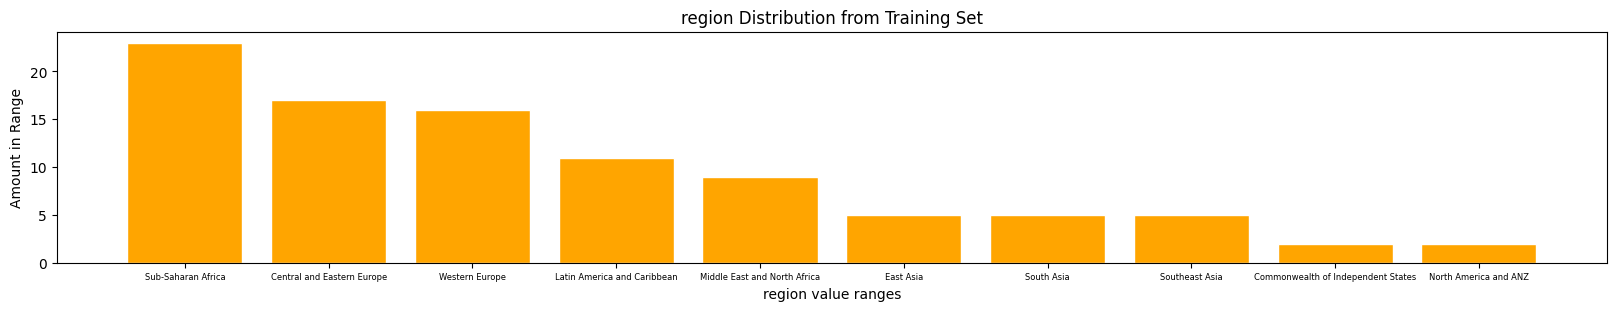

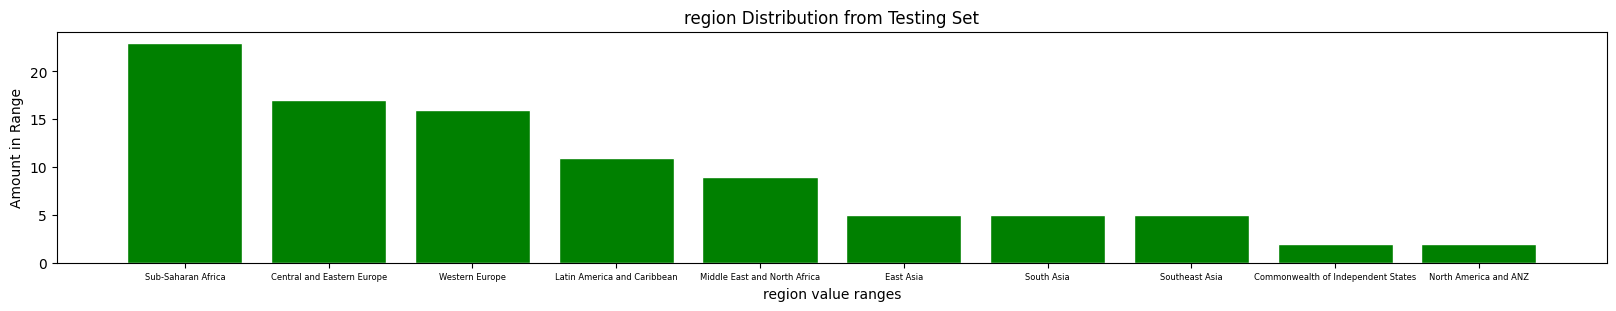

In [129]:
# Your plotting code here: TODO
# LEO: Our only categorical variable is the region of the countries (with the exception of country name)
# We need to redo the code for this plot because a categorical plot is slightly different
def plot_bar(source, variable):
  plt.figure(figsize=(20, 3))
  count = X_train[variable].value_counts()
  if source == "train":
    plt.bar(count.index, count.values, color='orange', edgecolor='white')
    plt.title(f'{variable} Distribution from Training Set')
  if source == "test":
    plt.bar(count.index, count.values, color='green', edgecolor='white')
    plt.title(f'{variable} Distribution from Testing Set')
  plt.xticks(fontsize=6) # added to make the categories fit
  plt.xlabel(f'{variable} value ranges')
  plt.ylabel('Amount in Range')
  plt.show()

plot_bar("train","region")
plot_bar("test","region")


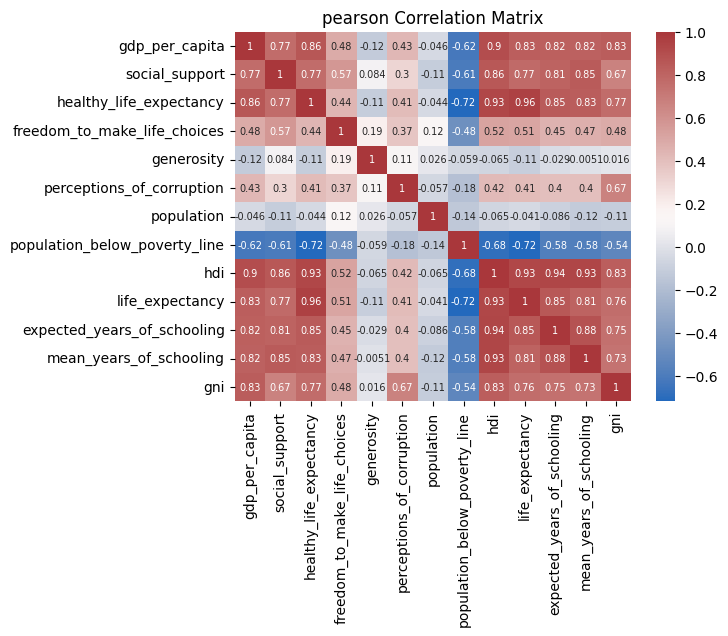

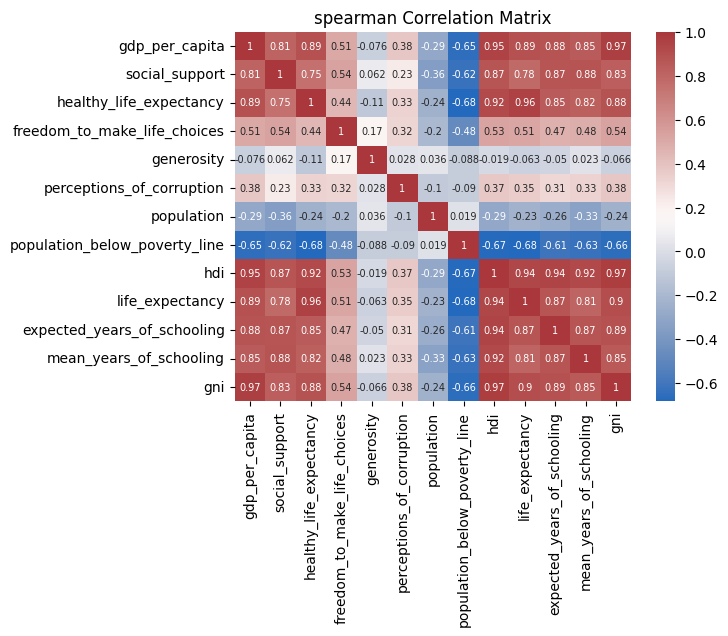

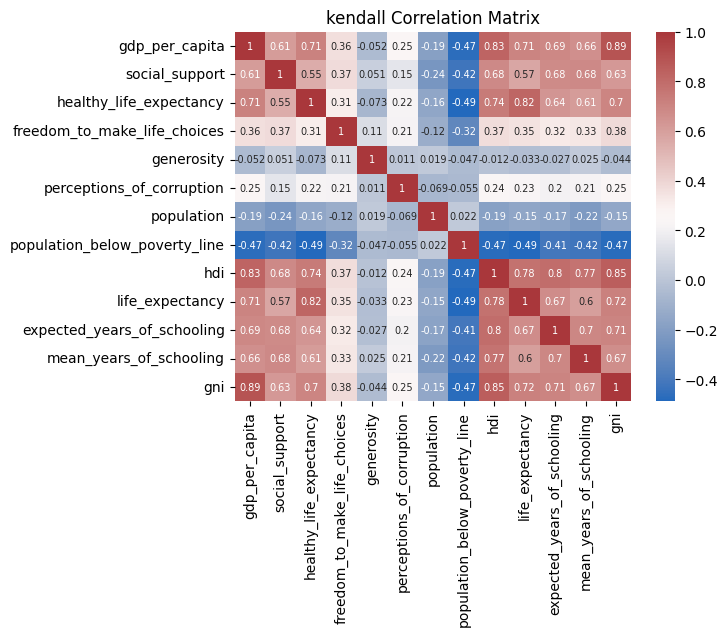

In [130]:
# Your code here: TODO
# LEO: we functionalize matrix creation using seaborn
import seaborn as sns
numerical_features_train = X_train.select_dtypes(include="number").columns # we only include numeric features for correlation matrices

# use plot_matrix to functionalize this process and not repeat
def plot_matrix (method):
  matrix = X_train[numerical_features_train].corr(method=method)
  sns.heatmap(matrix, annot=True, cmap='vlag',annot_kws={'size': 7}) # we use matrix, annot for values, cmap for color specification, and annot to reduce text size
  plt.title(f'{method} Correlation Matrix')
  plt.show()

plot_matrix("pearson")
plot_matrix("spearman")
plot_matrix("kendall")

**LEO**: [Brief Commentary] We clearly observe that along the diagonal line, correlations tend to be a perfect "1." This is because variables are perfectly correlated with themselves.

Outside of this, we notice a few things. First and foremost, hdi exhibits high correlation with expected years of schooling on multiple correlation matrices. This is because HDI is a combined weighted index of "Life expectancy," "Education," and "Standard of Living." Interestingly enough, the HDI—GNI relationship is higher on the kendall correlation than the hdi—life expectancy correlation, while it is lower on the pearson correlation. This indicates that it may have a lower raw linear correlation, but more rank-based multicollinearity.

Another factor that has high kendall/spearman and slightly lower (but high) spearman is the gni/gdp per capita relationship. This makes sense given that GNI is a measure of gross national income, so should be roughly on terms with GDP per capita (though GDP includes other factors like government expenditure, trade, etc.).

In terms of low correlation, population and generosity seem to be almost universally barely related to other variables. On all 3 correlation matrices, they hover close to 0 (the pale blue coloration that can be visualized in each).

Population below the poverty line, on the other hand, exhibits the strongest negative correlation across the map, which makes sense — as population below the poverty line increases, gdp per capita, gni, and other factors that are inversely related to poverty seem to go down.

### Bivariate Analysis and Relationship Exploration

Explore relationships between features and examine how they associate with the target variable. Include:

- Bivariate plots (e.g., scatter plots, box plots, grouped bar charts)
- Correlation tables
- Comparisons of feature distributions across target classes

Briefly summarize key relationships and any patterns that may influence model performance.

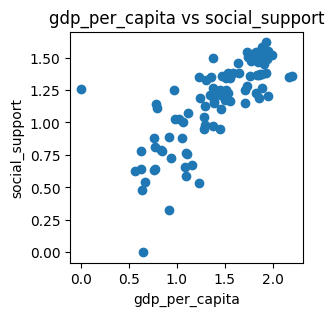

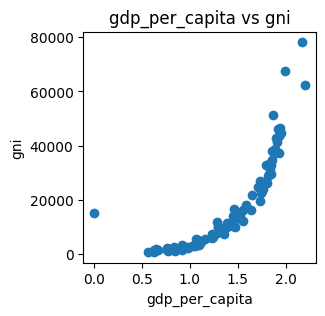

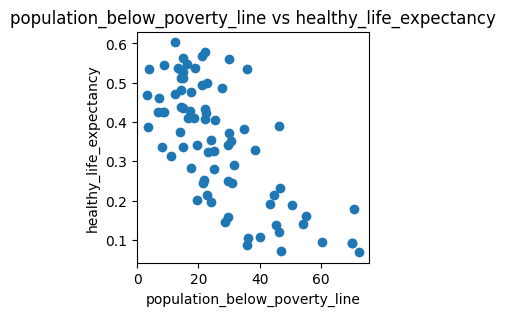

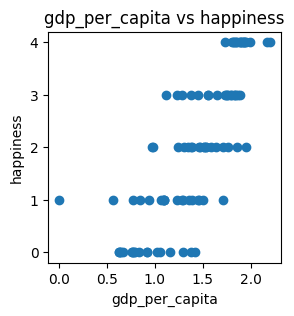

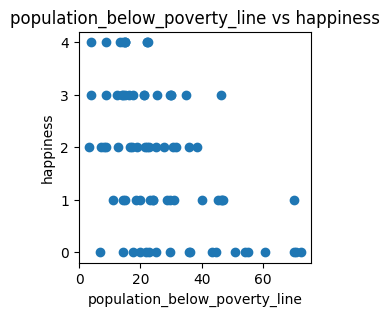

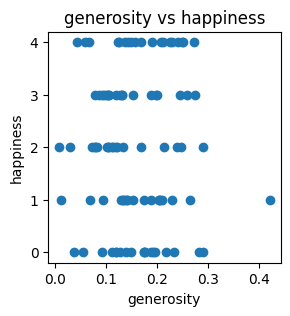

In [131]:
# LEO: scatter plots
# LEO: function for comparing multiple variables from X training
def x_scatter(a,b):
  plt.figure(figsize=(3,3))
  plt.scatter(X_train[a], X_train[b])
  plt.xlabel(f"{a}")
  plt.ylabel(f"{b}")
  plt.title(f'{a} vs {b}')
  plt.show()

# LEO: function for comparing X variable and Y variable
def y_scatter(a):
  plt.figure(figsize=(3,3))
  plt.scatter(X_train[a], y_train_labels)
  plt.title(f'{a} vs happiness')
  plt.xlabel(f"{a}")
  plt.ylabel(f"happiness")
  plt.show()


# LEO: bivariate scatter plot of gdp_per_capita vs. social_support
x_scatter("gdp_per_capita", "social_support")
x_scatter("gdp_per_capita","gni")
x_scatter("population_below_poverty_line","healthy_life_expectancy")
y_scatter("gdp_per_capita")
y_scatter("population_below_poverty_line")
y_scatter("generosity")

<Figure size 500x500 with 0 Axes>

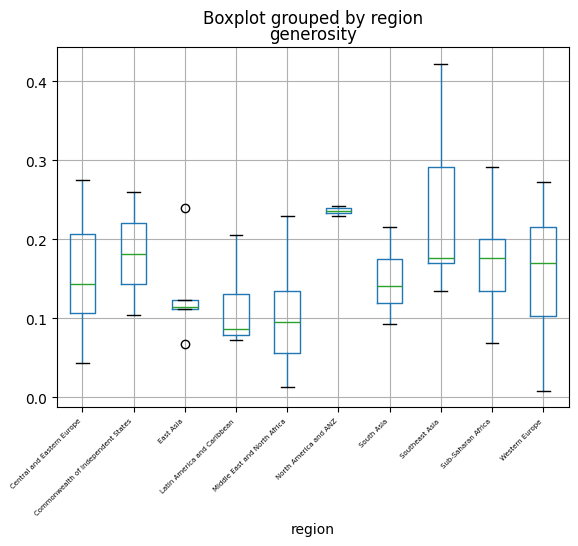

<Figure size 600x400 with 0 Axes>

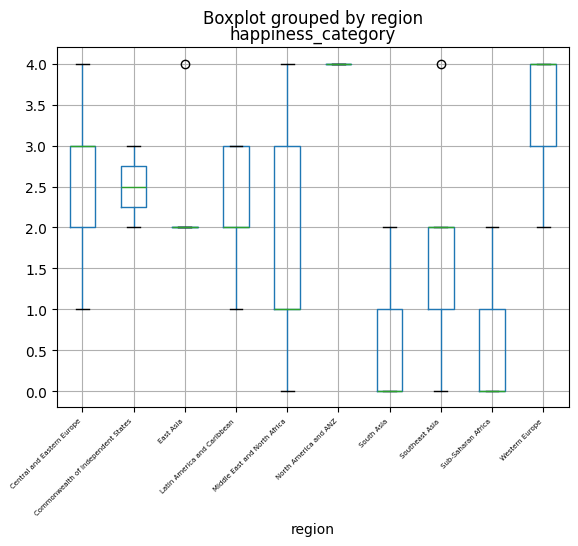

In [132]:
# LEO: box plots - we will do two box plots to save space here. We will show box plots for happiness by region.
def box_x(v1, v2):
    plt.figure(figsize=(5, 5))
    X_train.boxplot(column=v2, by=v1)
    plt.xticks(fontsize=5,rotation=45, ha='right') # right skew lines up with bars
    plt.show()

box_x("region","generosity")

def box_y(v1):
    plt.figure(figsize=(6, 4))
    # local object allows us to add y_train_labels values and create our chart
    local = X_train.copy()
    local['happiness_category'] = y_train_labels.values
    local.boxplot(column="happiness_category", by=v1)
    plt.xticks(fontsize=5,rotation=45, ha='right') # right skew lines up with bars
    plt.show()

box_y("region")

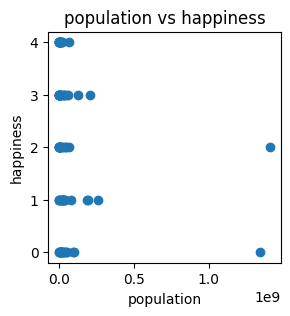

In [133]:
y_scatter("population")

In [134]:
X_train["population"].sort_values(ascending=False).head()

,population
92,1.409517e+09
20,1.339180e+09
46,2.639914e+08
39,2.092883e+08
77,1.970160e+08


<Figure size 600x400 with 0 Axes>

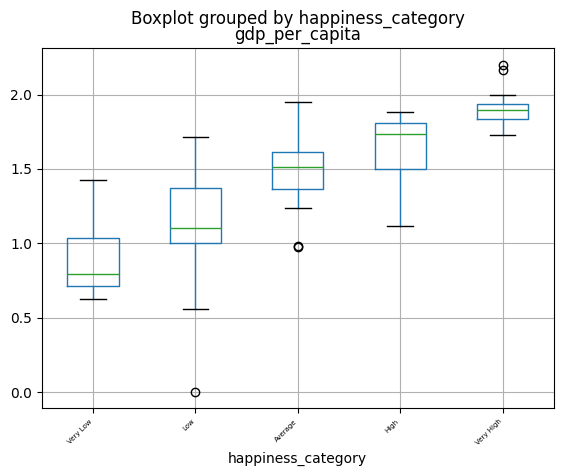

In [135]:
# LEO - box plots for categories of happiness compared to GDP per Capita lifting our code from above
plt.figure(figsize=(6, 4))
local2 = X_train.copy()
local2["happiness_category"] = y_train.values
local2.boxplot(column="gdp_per_capita", by="happiness_category")
plt.xticks(fontsize=5,rotation=45, ha="right") # right skew lines up with bars
plt.show()

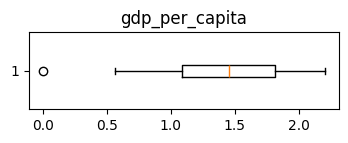

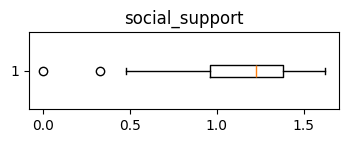

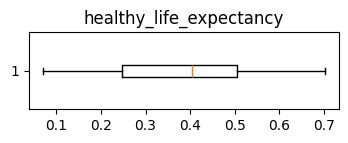

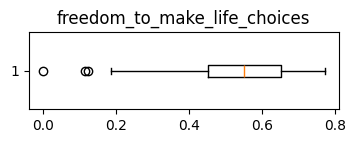

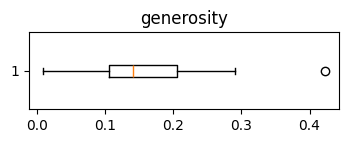

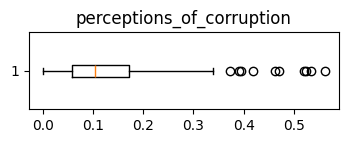

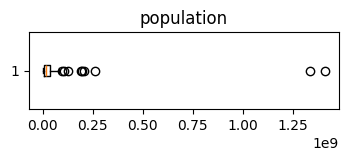

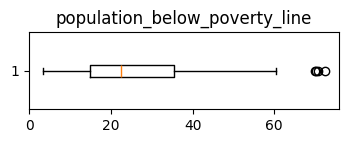

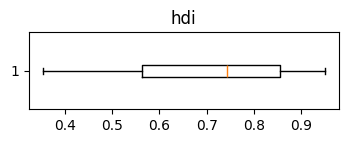

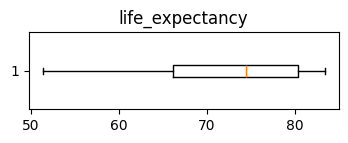

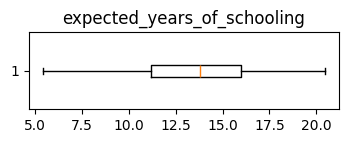

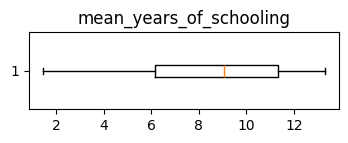

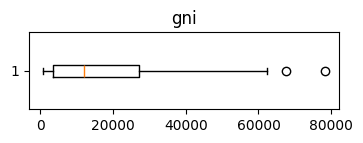

In [136]:
# LEO - the simplest way to find outliers is using for loop to create box plots.
for column_name in numerical_features_train:
    plt.figure(figsize=(4, 1))
    plt.boxplot(X_train[column_name].dropna(), vert = False, showfliers = True) # showfliers is critical so that we see dots for outliers (outside of normal IQR range)
    plt.title(column_name)
    plt.show()

---

# 2. Additional Processing/Feature Engineering

We include code necessary to run the best models for the purposes of this report.

In [137]:
print((X_train["gdp_per_capita"] < 0).sum())

0


In [138]:
# LEO - we select the columns with visible outliers in box plots to be scaled
import numpy as np # need numpy for log scaling
needs_fix = ["population", "gdp_per_capita", "social_support", "freedom_to_make_life_choices",
             "generosity","perceptions_of_corruption","population_below_poverty_line","gni"] # lot to be fixed!
for column_name in needs_fix:
  X_train[column_name] = np.log1p(X_train[column_name]) # we got a divide by zero warning and googled how to address that. log1p avoids the issue
  X_test[column_name] = np.log1p(X_test[column_name])

Create at least one interaction feature to capture relationships between existing variables and enhance predictive power.

In [139]:
# LEO - we are curious how social support from the government AND generosity improve the general mood and want to make an interaction with these
X_train["social_support_and_generosity"] = X_train["social_support"] * X_train["generosity"]
X_test["social_support_and_generosity"] = X_test["social_support"] * X_test["generosity"]

In [140]:
# MAISY
# Instead, I grouped some features together to keep it down to 5 features
conditions = {
    'Central and Eastern Europe': 'Europe',
    'Western Europe': 'Europe',
    'East Asia': 'Asia',
    'South Asia': 'Asia',
    'Southeast Asia': 'Asia',
    'Latin America and Caribbean': 'Others',
    'Commonwealth of Independent States': 'Others',
    'North America and ANZ': 'Others'
}
X_train['region'] = X_train['region'].replace(conditions)
X_test['region'] = X_test['region'].replace(conditions)

In [141]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ADDED - drop gdp_per_capita and health_life_expectancy from X_train and X_test
"""
X_train = X_train.drop(columns=['gdp_per_capita', 'healthy_life_expectancy'])
X_test = X_test.drop(columns=['gdp_per_capita', 'healthy_life_expectancy'])
"""
# removed, model performs better without the above lines

# Create the preprocessing pipelines for both numeric and categorical data.

numeric_features = X_train.select_dtypes(include='number') # same code as before ## Drop all the non-numerical features from X_train: TODO
numeric_features=numeric_features.columns.tolist()

numeric_transformer = Pipeline(steps=[
    # ('imputer', SimpleImputer(strategy='constant', fill_value=0)), ## Is this good enough?
    ('imputer', SimpleImputer(strategy='median')), # we change our strategy to median because the above assumes 0 is a good default
    ('scaler', StandardScaler())]) # You will need to describe why this is being done in the next cell

categorical_features = ['region'] #, 'sub-region'] ----- COMMENTED OUT BECAUSE WE HAVE NO SUB REGION

#Replacing missing values with Modal value and then one hot encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # most frequent is a modal approach
    ('onehot', OneHotEncoder(handle_unknown='ignore'))]) # not covered in recitation but found documentation that says smoothest operation is with 'ignore'

# final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

#Fit your preprocessor object
preprocess=preprocessor.fit(X_train)

In [142]:
# function to transform data with preprocessor

def preprocessor(data):
    data = data.drop(['country', 'country_name'], axis=1) # had to make this correct because it was not actually dropping that
    preprocessed_data=preprocess.transform(data)
    return preprocessed_data

In [143]:
# MAISY
# save the fitted preprocessor using joblib python library
import joblib
joblib.dump(preprocess, '/content/drive/MyDrive/preprocessor.joblib')

['/content/drive/MyDrive/preprocessor.joblib']

# 3. Reproduced Code for Best-Performing NON-deep learning models.

In this section, we include the code for the best two performing non-deep learning models from steps 4-6. These models are RFMODEL1 and KNN.

**Discussion**:
In steps 3-6 of our original source code notebook, we evaluate 6 models (3 random forest models, KNN, SVC, & GBM).

RFM1 does perform the best amongst its random forest peers, but all 3 of these models perform in the vein of 50-55% on accuracy (and similar F1 scores). Model 1 has the highest accuracy/precision/recall data for the particular random state of 165 for each.

*Why some did worse*: Because the support vector machine tries to make clear delineations, and given that our visualizations showed that we have a lot of overlap between different classes on different variable axes, things likely got muddy. Gradient boosting suffers because of our small sample size.

In our case, RFM1 and KNN are simpler models which tend to perform better under smaller sample sizes.

## a. RFMODEL1

In [144]:
# MAISY
# save the fitted preprocessor using joblib python library
import joblib
joblib.dump(preprocess, '/content/drive/MyDrive/preprocessor.joblib')

['/content/drive/MyDrive/preprocessor.joblib']

In [145]:
# MAISY
from sklearn.ensemble import RandomForestClassifier

scores = {}
X_train_preprocessed = preprocessor(X_train)
X_test_preprocessed = preprocessor(X_test)
print("Preprocessed X_train shape: ", X_train_preprocessed.shape)   # check to see if results match from above
print("Preprocessed X_test shape: ", X_test_preprocessed.shape)     # sanity check

model = RandomForestClassifier(random_state=165)

model.fit(X_train_preprocessed, y_train_labels)
model_score = model.score(X_test_preprocessed, y_test_labels)

print(f"Random Forest Model 1 Score: {round(model_score, 4)}")

Preprocessed X_train shape:  (95, 19)
Preprocessed X_test shape:  (42, 19)
Random Forest Model 1 Score: 0.5476


In [146]:
# MAISY
y_predicted = model.predict(X_test_preprocessed)

Accuracy Score: 0.5476190476190477
Accuracy for 0: 44.44%
Accuracy for 1: 50.00%
Accuracy for 2: 50.00%
Accuracy for 3: 62.50%
Accuracy for 4: 66.67%


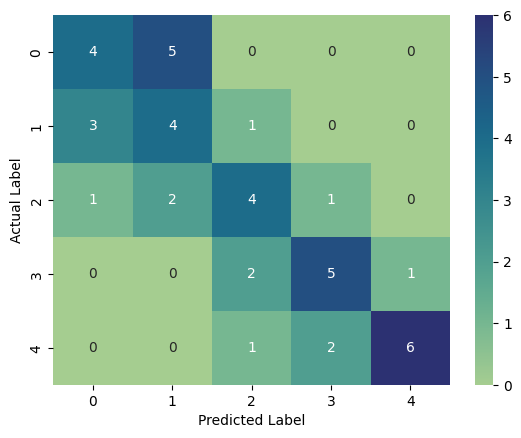

In [147]:
# MAISY
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
sns.color_palette('crest', as_cmap=True)

print(f"Accuracy Score: {accuracy_score(y_test_labels, y_predicted)}")

cm = confusion_matrix(y_test_labels, y_predicted)

sns.heatmap(cm, cmap='crest', annot=True)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label');

# This calculates the accuracies for each category. Since our data is multi-class
# classification, overall accuracy may not explain the true performance of the model
class_accuracies = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracies):
    print(f"Accuracy for {i}: {acc:.2%}")

## b. KNN MODEL code

In [148]:
# KNN ARCHITECTURE
from sklearn.neighbors import KNeighborsClassifier

## Read documentations of imported models and fit them. TODO
knn = KNeighborsClassifier()
knn.fit(X_train_preprocessed, y_train_labels)

knn_p = KNeighborsClassifier(n_neighbors=10, weights='distance')
knn_p.fit(X_train_preprocessed, y_train_labels)

print("Model Score for KNN: ", knn.score(X_test_preprocessed, y_test_labels))
print("Model Score for KNN w Params: ", knn_p.score(X_test_preprocessed, y_test_labels))

Model Score for KNN:  0.5952380952380952
Model Score for KNN w Params:  0.5238095238095238


KNN Accuracy for 1: 44.44%
KNN Accuracy for 1: 25.00%
KNN Accuracy for 1: 75.00%
KNN Accuracy for 1: 50.00%
KNN Accuracy for 1: 66.67%




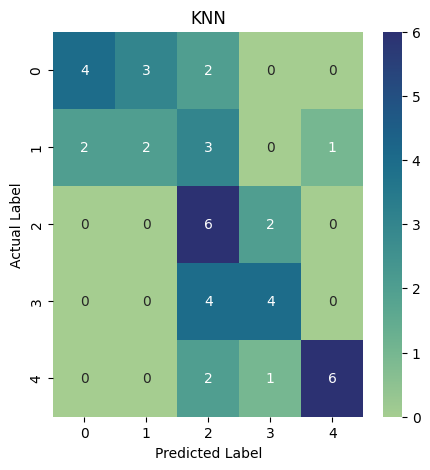

In [149]:
# MAISY
fig, axs = plt.subplots(1, 1, figsize=(5,5))

y_predicted = knn_p.predict(X_test_preprocessed)
scores['KNN'] = [accuracy_score(y_test_labels, y_predicted), \
               precision_score(y_test_labels, y_predicted, average='weighted'), \
               recall_score(y_test_labels, y_predicted, average='weighted'), \
               f1_score(y_test_labels, y_predicted, average='weighted')]

cm = confusion_matrix(y_test_labels, y_predicted)
axs.set_title('KNN')
sns.heatmap(cm, cmap='crest', annot=True, ax=axs)
axs.set_xlabel('Predicted Label')
axs.set_ylabel('Actual Label')
class_accuracies = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracies):
    print(f"{a} Accuracy for 1: {acc:.2%}")
print("\n")

---

## 4. Strongest Deep Learning Model

Out of the 5 models we tested, we experienced the best consistency/performance with the leakyrelu model. Sigmoid exhibited an equivalent testing set score, but had a wide gap with the training data score (~30% accuracy in training, ~50% in testing), so we felt more compelled by the results of the leakyrelu model. Generally, we maintained 300 epochs to stick with the consistency of the assignment, but I (Leo) found that model performance actually improved on deep learning with 200 or 250 epochs, potentially indicating some overfitting at hand.

In general, it is interesting to note that our deep learning models did not display staggering outperformance of the initial tree/KNN models that we used on this data. We believe this is likely related to the small size of the dataset (95 samples in total, not to mention training split in place). This also explains behavior in our first model (incredibly high training set accuracy of 95% but shocking drop to ~50% for testing data) — the epoch count, small data size, and complexity of the deep learning model are all actually limiting factors.

More time allowing, it would be interesting to significantly simplify the epoch size, play around with a different train/test split, and continue to refine these models.

**CODE BELOW FOR LEAKY RELU**

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.1705 - loss: 1.8989 - val_accuracy: 0.3333 - val_loss: 1.5752
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.2554 - loss: 1.9128 - val_accuracy: 0.2500 - val_loss: 1.5706
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2491 - loss: 1.8004 - val_accuracy: 0.2500 - val_loss: 1.5740
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2843 - loss: 1.6976 - val_accuracy: 0.2500 - val_loss: 1.5705
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1563 - loss: 1.7807 - val_accuracy: 0.2083 - val_loss: 1.5680
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.2337 - loss: 1.6570 - val_accuracy: 0.2500 - val_loss: 1.5670
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.3212 - loss: 1.7900 - val_accuracy: 0.2500 - val_loss: 1.5643
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3293 - loss: 1.6007 - val_accuracy: 0.2500 - val_loss: 1.5584
Ep

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Deep Learning Model with LeakyReLU Accuracy Score: 0.5238


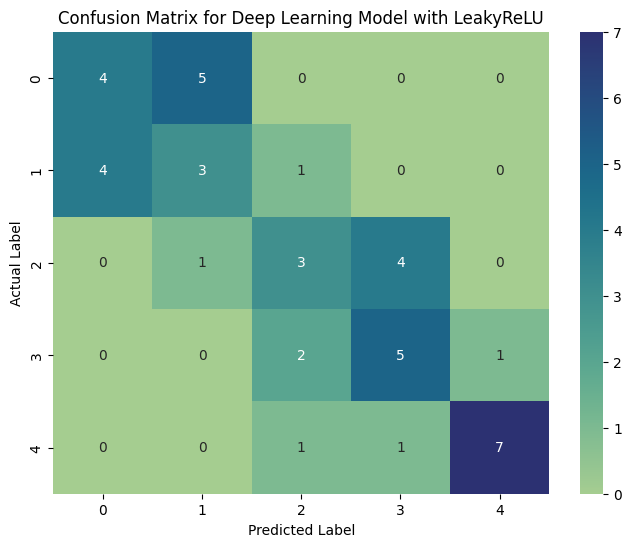

Accuracy for class 0 (LeakyReLU): 44.44%
Accuracy for class 1 (LeakyReLU): 37.50%
Accuracy for class 2 (LeakyReLU): 37.50%
Accuracy for class 3 (LeakyReLU): 62.50%
Accuracy for class 4 (LeakyReLU): 77.78%


In [150]:
# Your lines of code here
# Siyi

import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, BatchNormalization, LeakyReLU
from keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from keras.layers import LeakyReLU

feature_count = X_train_preprocessed.shape[1]
num_classes = len(np.unique(y_train_labels))
y_train_one_hot = to_categorical(y_train_labels, num_classes=num_classes)

# Model with LeakyReLU activation
keras_model_leaky_relu = Sequential([
    Dense(128, input_dim=feature_count),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(32),
    BatchNormalization(),
    LeakyReLU(alpha=0.01), # Using LeakyReLU
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Compile model
keras_model_leaky_relu.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Fitting the NN to the Training set
history_leaky_relu = keras_model_leaky_relu.fit(X_train_preprocessed, y_train_one_hot,
               batch_size = 20,
               epochs = 300, validation_split=0.25)

print("\n--- Evaluating LeakyReLU Model ---")
# Generate predictions
prediction_column_index_leaky_relu = keras_model_leaky_relu.predict(X_test_preprocessed)
prediction_labels_leaky_relu = np.argmax(prediction_column_index_leaky_relu, axis=1)

# Evaluate performance
accuracy_leaky_relu = accuracy_score(y_test_labels, prediction_labels_leaky_relu)
print(f"Deep Learning Model with LeakyReLU Accuracy Score: {accuracy_leaky_relu:.4f}")

cm_leaky_relu = confusion_matrix(y_test_labels, prediction_labels_leaky_relu)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_leaky_relu, annot=True, fmt='d', cmap='crest')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Deep Learning Model with LeakyReLU')
plt.show()

class_accuracies_leaky_relu = cm_leaky_relu.diagonal() / cm_leaky_relu.sum(axis=1)

for i, acc in enumerate(class_accuracies_leaky_relu):
    print(f"Accuracy for class {i} (LeakyReLU): {acc:.2%}")